In [4]:
# Autoreload extension
%load_ext autoreload
%autoreload 2


In [13]:
import torch

from alphazero_less_simple.benchmarks.arena import Arena
from alphazero_less_simple.benchmarks.full import FullBenchmark
from alphazero_less_simple.benchmarks.mcts_only import MCTSOnlyBenchmark
from alphazero_less_simple.benchmarks.network_only import NetworkOnlyBenchmark

In [17]:
from alphazero_simple.connect4_game import Connect4Game

game = Connect4Game()
board_size = game.get_board_size()
action_size = game.get_action_size()

arena = Arena(game)


In [18]:
from alphazero_simple.resnet import ResNet

model = ResNet(board_size, action_size, 9, 128)


# Test individual model

In [ ]:
# model_path = "/Users/pveron/Code/alphazero-implementation/src/alphazero_less_simple/lightning_logs/alphazero_less_simple/run_010_ResNet_iter25_episodes500_sims600/checkpoints/epoch=0-step=159.ckpt"
# model_path = "/Users/pveron/Code/alphazero-implementation/src/alphazero_less_simple/lightning_logs/alphazero_less_simple/run_010_ResNet_iter25_episodes500_sims600/checkpoints/epoch=18-step=44682.ckpt"
model_path = "/Users/pveron/Code/alphazero-implementation/src/alphazero_less_simple/lightning_logs/alphazero_less_simple/run_010_ResNet_iter25_episodes500_sims600/checkpoints/epoch=22-step=66639.ckpt"
model.load_state_dict(torch.load(model_path, weights_only=True)["state_dict"])


In [16]:
mcts_only = MCTSOnlyBenchmark(game, num_simulations=1000, temperature=0.2)
full = FullBenchmark(game, model, num_simulations=600)
network_only = NetworkOnlyBenchmark(game, model)

arena = Arena(game)

In [ ]:
arena.play_game(full, mcts_only)


In [ ]:
arena.play_matches(full, mcts_only, 10)

In [ ]:
arena.play_matches(network_only, mcts_only, 5)

In [ ]:
arena.play_matches(mcts_only, network_only, 5)

In [ ]:
arena.play_matches(mcts_only, mcts_only, 10)


In [ ]:
arena.play_matches(network_only, network_only, 100)

# Benchmark

In [19]:
import re
from pathlib import Path

import matplotlib.pyplot as plt

checkpoints_dir = Path(
    "/Users/pveron/Code/alphazero-implementation/src/alphazero_less_simple/lightning_logs/alphazero_less_simple/run_010_ResNet_iter25_episodes500_sims600/checkpoints"
)
checkpoint_files = list(checkpoints_dir.glob("*.ckpt"))
if not checkpoint_files:
    print("No checkpoints found")
else:
    # Sort by modification time to get latest first
    checkpoint_files = sorted(checkpoint_files, key=lambda p: p.stat().st_mtime)
    for checkpoint_file in checkpoint_files:
        print(checkpoint_file.name)


epoch=0-step=159.ckpt
epoch=1-step=485.ckpt
epoch=2-step=988.ckpt
epoch=3-step=1721.ckpt
epoch=4-step=2683.ckpt
epoch=5-step=3892.ckpt
epoch=6-step=5370.ckpt
epoch=7-step=7107.ckpt
epoch=8-step=9123.ckpt
epoch=9-step=11417.ckpt
epoch=10-step=13998.ckpt
epoch=11-step=16869.ckpt
epoch=12-step=20019.ckpt
epoch=13-step=23445.ckpt
epoch=14-step=27149.ckpt
epoch=15-step=31123.ckpt
epoch=16-step=35367.ckpt
epoch=17-step=39882.ckpt
epoch=18-step=44682.ckpt
epoch=19-step=49749.ckpt
epoch=20-step=55098.ckpt
epoch=21-step=60726.ckpt
epoch=22-step=66639.ckpt


In [25]:
def plot_win_rates(iterations, full_win_rates, network_win_rates, save_path):
    # Create single plot after all data is collected
    plt.figure(figsize=(12, 8))
    plt.plot(iterations, full_win_rates, "b-o", label="Full (MCTS + Network)")
    plt.plot(iterations, network_win_rates, "r-o", label="Network Only")

    # Customize the grid
    plt.grid(True, linestyle="--", alpha=0.2, color="gray")

    # Set axis limits
    plt.ylim(0, 100)
    plt.xlim(0, max(iterations))

    # Set x-axis ticks to increment by 1
    plt.xticks(range(0, max(iterations) + 1, 1))

    # Customize labels and title
    plt.xlabel("Iteration")
    plt.ylabel("Win Rate vs MCTS (%)")  # Added % for clarity
    plt.title("AlphaZero Performance Evolution")

    # Customize legend
    plt.legend(bbox_to_anchor=(1.02, 0.1), loc="lower right", fontsize=10)

    # Adjust layout to prevent label cutoff
    plt.tight_layout()

    # Save and show the final plot
    plt.savefig(save_path)

In [26]:
import json
from pathlib import Path


def save_progress(iterations, full_win_rates, network_win_rates):
    results_dir = Path("results")
    results_dir.mkdir(exist_ok=True)

    # Save data as JSON
    results = {
        "iterations": iterations,
        "full_win_rates": full_win_rates,
        "network_win_rates": network_win_rates,
    }

    with open(results_dir / "win_rates.json", "w") as f:
        json.dump(results, f, indent=4)

In [29]:
import tqdm

# Lists to store results
iterations = []
full_win_rates = []
network_win_rates = []
number_of_matches = 50


for checkpoint_file in tqdm.notebook.tqdm(
    checkpoint_files, desc="Processing checkpoints", position=0
):
    # Extract epoch number from filename
    iteration = int(re.search(r"epoch=(\d+)", checkpoint_file.name).group(1))  # type: ignore[union-attr]

    model.load_state_dict(torch.load(checkpoint_file, weights_only=True)["state_dict"])
    full = FullBenchmark(game, model, num_simulations=600, temperature=0.2)
    mcts_only = MCTSOnlyBenchmark(game, num_simulations=1000, temperature=0.2)
    network_only = NetworkOnlyBenchmark(game, model, temperature=0.5)

    print(f"Iteration: {iteration}")
    print(f"Checkpoint: {checkpoint_file.name}")

    full_wins, full_losses, full_draws = arena.play_matches(
        full, mcts_only, number_of_matches, 1
    )

    # Calculate win rates
    full_win_rate = full_wins / number_of_matches * 100

    print(
        f"Full wins: {full_wins}, Full losses: {full_losses}, Full draws: {full_draws}, Full win rate: {full_win_rate:.2f}%"
    )
    network_wins, network_losses, network_draws = arena.play_matches(
        network_only, mcts_only, number_of_matches, 1
    )

    network_win_rate = network_wins / number_of_matches * 100

    print(
        f"Network wins: {network_wins}, Network losses: {network_losses}, Network draws: {network_draws}, Network win rate: {network_win_rate:.2f}%"
    )

    # Store results
    iterations.append(iteration)
    full_win_rates.append(full_win_rate)
    network_win_rates.append(network_win_rate)

    plot_win_rates(
        iterations, full_win_rates, network_win_rates, f"win_rates_{iteration}.png"
    )
    plt.close()

    save_progress(iterations, full_win_rates, network_win_rates)

Processing checkpoints:   0%|          | 0/23 [00:00<?, ?it/s]

Iteration: 0
Checkpoint: epoch=0-step=159.ckpt


Playing games (FullBenchmark vs MCTSOnlyBenchmark):   0%|          | 0/50 [00:00<?, ?it/s]

Full wins: 18, Full losses: 30, Full draws: 2, Full win rate: 36.00%


Playing games (NetworkOnlyBenchmark vs MCTSOnlyBenchmark):   0%|          | 0/50 [00:00<?, ?it/s]

...

Network wins: 36, Network losses: 11, Network draws: 3, Network win rate: 72.00%
Iteration: 22
Checkpoint: epoch=22-step=66639.ckpt


Playing games (FullBenchmark vs MCTSOnlyBenchmark):   0%|          | 0/50 [00:00<?, ?it/s]

Full wins: 49, Full losses: 1, Full draws: 0, Full win rate: 98.00%


Playing games (NetworkOnlyBenchmark vs MCTSOnlyBenchmark):   0%|          | 0/50 [00:00<?, ?it/s]

Network wins: 41, Network losses: 8, Network draws: 1, Network win rate: 82.00%


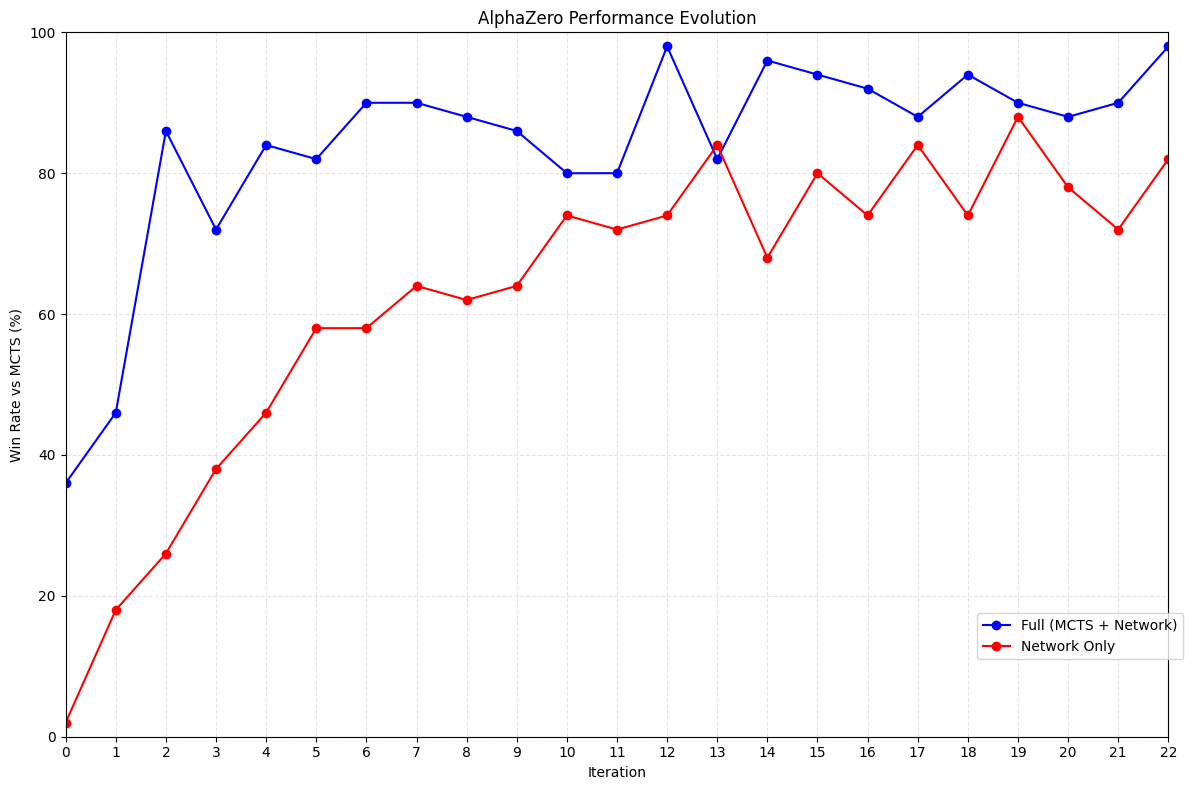

In [30]:
plot_win_rates(iterations, full_win_rates, network_win_rates, "win_rates_final.png")
plt.show()